# Generación de Isócronas y Asignación a Zonas Censales para Trabajo Final

## 1. Instalación de paquetes



In [97]:
!pip install osmnx
!pip install geopandas
!pip install shapely

##  2. Librerías

In [98]:
import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape, Point
from shapely.wkt import loads

## 3. Carga de archivos

In [99]:
from google.colab import files
uploaded = files.upload()

Saving comunas_gs.geojson to comunas_gs (1).geojson
Saving manzanas_tiendas.geojson to manzanas_tiendas (1).geojson
Saving tiendas_naturistas.geojson to tiendas_naturistas (1).geojson


renombramos los archivos

In [100]:
# Lectura de archivos (SRC original: EPSG:32719)
zc_tiendas = gpd.read_file("manzanas_tiendas.geojson")
tiendas = gpd.read_file("tiendas_naturistas.geojson")
comunas = gpd.read_file("comunas_gs.geojson")

<Axes: >

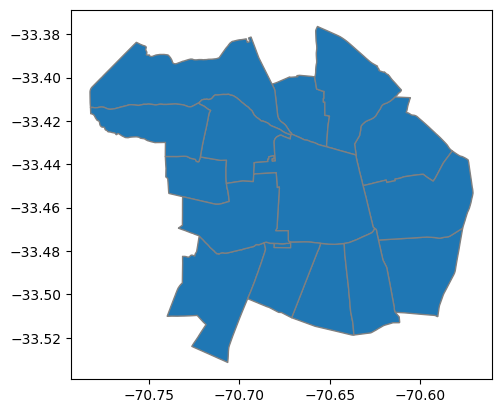

In [101]:
# Visualizamos las comunas seleccionadas
comunas.plot(edgecolor='gray')

## 🚶‍♂️ 4. Descarga de red vial peatonal desde OpenStreetMap

Descargamos la red vial para el tener el grafo y trabajar más adelante.



In [119]:
# dejamos la misma proyeccion
comunas = comunas.to_crs("EPSG:32719")  # zona UTM Chile
tiendas = tiendas.to_crs("EPSG:32719")
zc_tiendas = zc_tiendas.to_crs("EPSG:32719")

In [120]:
# Crear buffer de 1000 metros alrededor del polígono comunal
buffer_comuna = comunas.buffer(1000).to_crs("EPSG:4326").iloc[0]

In [121]:
from shapely.geometry import MultiPoint

# Convertir a CRS 4326 y crear envolvente de todas las tiendas
tiendas_wgs84 = tiendas.to_crs("EPSG:4326")
puntos_union = MultiPoint([geom for geom in tiendas_wgs84.geometry])
bbox_tiendas = puntos_union.buffer(0.01)  # puedes ajustar el buffer si quieres más área

# Descargar red caminable para TODAS las tiendas
G = ox.graph_from_polygon(bbox_tiendas, network_type='walk')

# Asignar velocidad y calcular tiempos
ox.settings.default_speed_walk = 5
for u, v, k, data in G.edges(keys=True, data=True):
    data['speed_kph'] = 5
G = ox.add_edge_travel_times(G)


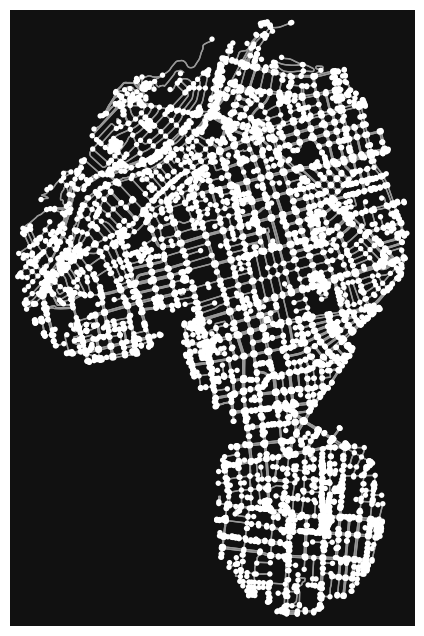

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [122]:
# Visualizar grafo
ox.plot_graph(G)

## 5. Prueba de isocróna en una sola tienda

In [123]:
# Seleccionar una tienda
punto = tiendas.to_crs("4326").geometry.iloc[0]
## transformar la tienda
origen = ox.nearest_nodes(G, punto.x, punto.y)
## ve el nodo mas cercano a mi punto y en base a ese, calcula la distancia

In [124]:
# Crear subgrafo de 15 minutos caminando (900 segundos)
subgraph = nx.ego_graph(G, origen, radius=900, distance='travel_time')
## le pasamos el tiempo de distancia, quier ver a cuales puntos a partir de mi punto puedo llegar en 10 min
nodos_iso = list(subgraph.nodes)

In [125]:
# Convertir nodos a GeoDataFrame
nodos_geom = [Point((G.nodes[n]['x'], G.nodes[n]['y'])) for n in nodos_iso]
## area de influencia
gdf_iso = gpd.GeoDataFrame(geometry=nodos_geom, crs="EPSG:4326")

<Axes: >

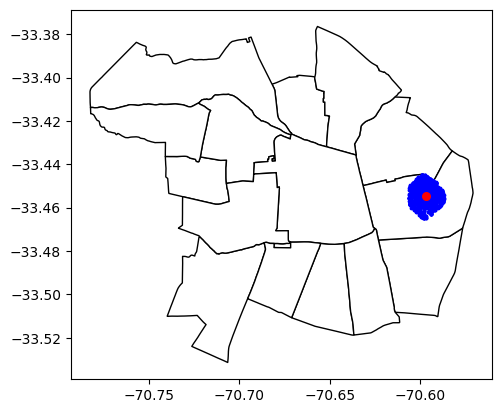

In [126]:
# Visualizar isócrona de un solo punto
base = comunas.to_crs("4326").plot(color='white', edgecolor='black')
gdf_iso.plot(ax=base, color='blue', markersize=3)
tiendas.to_crs("4326").iloc[[0]].plot(ax=base, color='red', markersize=30)

## 6. Isócronas desde todos las tiendas


In [129]:
## ESTO SIRVE PARA EL TRABAJO FINAL PARA LAS ISOCRONAS
# Convertir todo a WGS84
tiendas = tiendas.to_crs("4326")

# Inicializar set de nodos accesibles
todos_nodos_iso = set()

# Recorrer todos los minimarkets y acumular nodos accesibles
## tomo todos los puntos de mi lista
for idx, row in tiendas.iterrows():
    punto = row.geometry
    try:
        origen = ox.nearest_nodes(G, punto.x, punto.y)
        subgraph = nx.ego_graph(G, origen, radius=600, distance='travel_time')
        nodos_iso = list(subgraph.nodes)
        todos_nodos_iso.update(nodos_iso)
    except Exception as e:
        print(f"Error en minimarket {idx}: {e}")


In [131]:
# Convertir nodos a GeoDataFrame
nodos_geom = [Point((G.nodes[n]['x'], G.nodes[n]['y'])) for n in todos_nodos_iso]
gdf_iso_all = gpd.GeoDataFrame(geometry=nodos_geom, crs="EPSG:4326")

<Axes: >

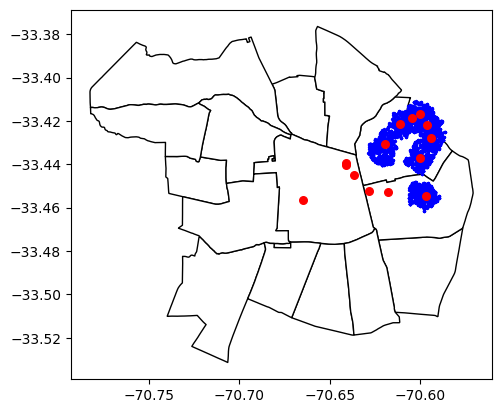

In [132]:
# Visualizar cobertura total
base = comunas.to_crs("4326").plot(color='white', edgecolor='black')
gdf_iso_all.plot(ax=base, color='blue', markersize=2)
tiendas.plot(ax=base, color='red', markersize=30)

## 7. Creación del polígono de isócrona combinado

In [133]:
# Crear polígono envolvente (convex hull)
isocrona_area = gdf_iso_all.union_all().convex_hull
## convex_hull calcula lo que envuelve a todos los puntos

# Reproyectar a EPSG:32719
isocrona_area = gpd.GeoSeries([isocrona_area], crs="EPSG:4326").to_crs(zc_tiendas.crs).geometry.iloc[0]

##  8. Evaluar cobertura por centroide

In [134]:
# Calcular centroides
zc_tiendas['centroide'] = zc_tiendas.geometry.centroid

# Verificar si el centroide está dentro del área de la isócrona
zc_tiendas['cobertura_centroide'] = zc_tiendas['centroide'].within(isocrona_area)
## para ver el porcentaje que abarca el centroide en la zona

## 🗺️ 9. Visualización final de zonas cubiertas

<Axes: >

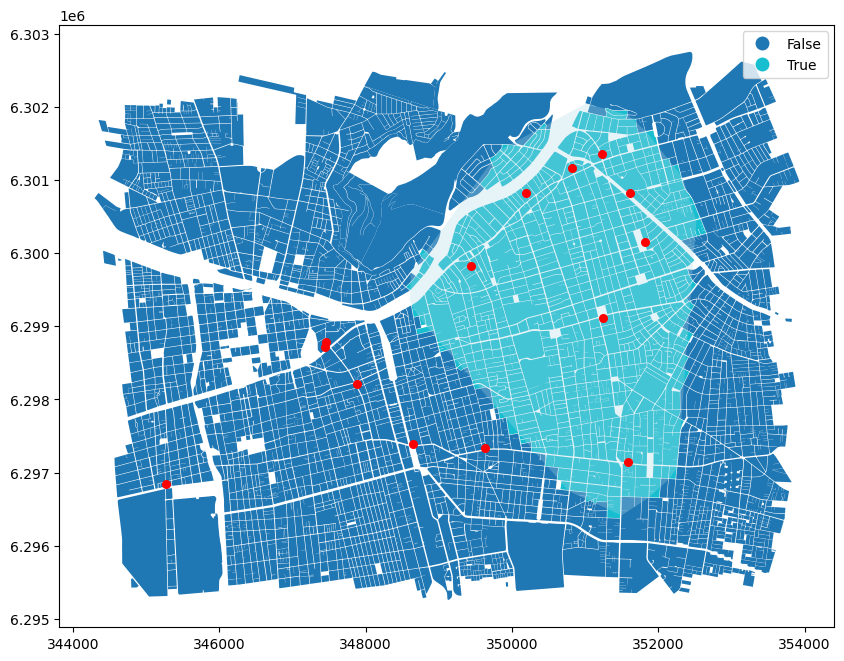

In [135]:
# Confirmar reproyección a EPSG:32719
zc_tiendas = zc_tiendas.to_crs("EPSG:32719")

# Visualizar resultado
base = zc_tiendas.plot(column='cobertura_centroide', categorical=True, legend=True, figsize=(10, 8))
gpd.GeoSeries([isocrona_area], crs=zc_tiendas.crs).plot(ax=base, color='lightblue', alpha=0.3)
tiendas.to_crs("EPSG:32719").plot(ax=base, color='red', markersize=30)
